# 06 Evaluation Script

##Set up

In [ ]:
requirements_path = '../requirements.txt'

!pip install -r "$requirements_path"

In [ ]:
import os
import tensorflow as tf
import tf_keras as keras
import numpy as np
from sklearn.model_selection import train_test_split
from tf_keras.models import load_model
import akida
import quantizeml
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Force legacy Keras BEFORE importing TensorFlow
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Notice the double underscores!
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras module: {keras.__name__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.19.1
Keras module: tf_keras
Keras version: 2.19.0


## Dataset

In [ ]:
# Path to the dataset and labels in Google Drive
dataset_path = '/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/processed_data/X_watch_20Hz_scaled_small.npy'
labels_path = '/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/processed_data/y_watch_labels_small.npy'

try:
    # Load .npy files using numpy.load
    X_data = np.load(dataset_path)
    y_labels = np.load(labels_path).astype(np.int32)

    print(f"Dataset loaded successfully from: {dataset_path}")
    print(f"Labels loaded successfully from: {labels_path}")

    print(f"\nX_data shape: {X_data.shape}")
    print(f"y_labels shape: {y_labels.shape}, dtype: {y_labels.dtype}")

except FileNotFoundError:
    print(f"Error: One or both files were not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset loaded successfully from: /content/drive/MyDrive/Project MLA - On Edge Motion Recognition/processed_data/X_watch_20Hz_scaled_small.npy
Labels loaded successfully from: /content/drive/MyDrive/Project MLA - On Edge Motion Recognition/processed_data/y_watch_labels_small.npy

X_data shape: (64687, 40, 6)
y_labels shape: (64687,), dtype: int32


In [ ]:
def split_and_save_dataset(X, y, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train_size, random_state=random_state, stratify=y
    )

    relative_val_size = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=relative_val_size, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [35]:
X_train, X_val, X_test, y_train, y_val, y_test = split_and_save_dataset(X_data, y_labels, train_size=0.7, val_size=0.15, test_size=0.15)

# We remap the labels to a continuous interval [0, N-1]
unique_labels = np.unique(y_train)
label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}

def apply_mapping(labels, mapping):
    return np.array([mapping[label] for label in labels], dtype=np.int32)

y_train = apply_mapping(y_train, label_mapping)
y_val = apply_mapping(y_val, label_mapping)
y_test = apply_mapping(y_test, label_mapping)

num_classes = len(unique_labels)

print(f"Number of unique classes detected: {num_classes}")
print(f"Applied mapping: {label_mapping}")
print(f"X_train dimensions: {X_train.shape}, y_train: {y_train.shape}")

Number of unique classes detected: 7
Applied mapping: {np.int32(5): 0, np.int32(6): 1, np.int32(13): 2, np.int32(14): 3, np.int32(15): 4, np.int32(16): 5, np.int32(17): 6}
X_train dimensions: (45280, 40, 6), y_train: (45280,)


In [36]:
activity_id_to_name = {
    5: 'Typing',
    6: 'Teeth',
    13: 'Catch',
    14: 'Dribbling',
    15: 'Writing',
    16: 'Clapping',
    17: 'Folding'
}


# Create an ordered list of original labels based on the `label_mapping` values
ordered_original_labels = sorted(label_mapping, key=label_mapping.get)

# Get the activity names in the correct order for the confusion matrix axes
activity_names_for_cm = [activity_id_to_name[label] for label in ordered_original_labels]

In [37]:
# Input reshape
X_train_reshaped = X_train.reshape(-1, 40, 6, 1)
X_val_reshaped = X_val.reshape(-1, 40, 6, 1)
X_test_reshaped = X_test.reshape(-1, 40, 6, 1)

pad_config = ((0,0), (0,1), (1,2), (0,0))
X_train_padded = np.pad(X_train_reshaped, pad_width=pad_config, mode='constant', constant_values=0)
X_val_padded = np.pad(X_val_reshaped, pad_width=pad_config, mode='constant', constant_values=0)
X_test_padded = np.pad(X_test_reshaped, pad_width=pad_config, mode='constant', constant_values=0)

x_min = np.min(X_train_padded)
x_max = np.max(X_train_padded)

# Range [0.0, 1.0] in float32
X_train = ((X_train_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)
X_val = ((X_val_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)
X_test = ((X_test_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)

## Evaluation

In [ ]:
model_path_fb = '/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/best/SMALL_FinalModel_quantized_akida.fb'

saved_model = akida.Model(model_path_fb)
print("Akida SNN model loaded successfully from the .fb file!")

saved_model.summary()

# Evaluation on Test Set
print("\n--- Evaluation on Test Set (Akida Execution) ---")

test_accuracy = saved_model.evaluate(X_test, y_test)
print(f"Test Accuracy of Akida SNN model: {test_accuracy * 100:.2f}%")

Akida SNN model loaded successfully from the .fb file!
                Model Summary                 
______________________________________________
Input shape  Output shape  Sequences  Layers
[41, 9, 1]   [1, 1, 7]     1          8     
______________________________________________

____________________________________________________________
Layer (type)                 Output shape  Kernel shape   

=========== SW/input_quantizer-dense_2 (Software) ==========

input_quantizer (Quantizer)  [41, 9, 1]    N/A            
____________________________________________________________
conv2d (InputConv.)          [21, 5, 32]   (3, 3, 1, 32)  
____________________________________________________________
conv2d_1 (Conv.)             [11, 3, 64]   (3, 3, 32, 64) 
____________________________________________________________
conv2d_2 (Conv.)             [6, 2, 128]   (3, 3, 64, 128)
____________________________________________________________
conv2d_3 (Conv.)             [6, 2, 48]    (1, 1, 

## Hardware

In [ ]:
# Load Model First
model_path = '/content/drive/MyDrive/Project MLA - On Edge Motion Recognition/models/best/SMALL_FinalModel_quantized_akida.fb'
akida_model = akida.Model(model_path)
print("SNN model loaded into memory.")

# Hardware Detection
available_devices = akida.devices()

if len(available_devices) == 0:
    print("\nNo physical Akida hardware detected! The code will use the software simulator.")
elif len(available_devices) > 0:
    device = available_devices[0]
    print(f"\nPhysical hardware successfully detected: {device}")

    akida_model.map(device)
    print(f"Model mapped and executed on hardware.")

akida_model.summary()

# Inference
# If .map() was called, this runs on the AKD1000
# If .map() was skipped, this automatically runs on the CPU Simulator
print("\n--- Starting inference ---")
test_samples = X_test
preds = akida_model.predict(test_samples)

akida_preds = np.argmax(preds, axis=-1).flatten()
akida_accuracy = np.mean(akida_preds == y_test)
print(f"Akida Accuracy: {akida_accuracy * 100:.2f}%")

print("\n--- Execution statistics ---")
print(akida_model.statistics)

SNN model loaded into memory.

No physical Akida hardware detected! The code will use the software simulator.
                Model Summary                 
______________________________________________
Input shape  Output shape  Sequences  Layers
[41, 9, 1]   [1, 1, 7]     1          8     
______________________________________________

____________________________________________________________
Layer (type)                 Output shape  Kernel shape   

=========== SW/input_quantizer-dense_2 (Software) ==========

input_quantizer (Quantizer)  [41, 9, 1]    N/A            
____________________________________________________________
conv2d (InputConv.)          [21, 5, 32]   (3, 3, 1, 32)  
____________________________________________________________
conv2d_1 (Conv.)             [11, 3, 64]   (3, 3, 32, 64) 
____________________________________________________________
conv2d_2 (Conv.)             [6, 2, 128]   (3, 3, 64, 128)
________________________________________________________

## Confusion Matrix

Confusion Matrix:
[[1208    2    1    1   92    3   13]
 [   6 1303    1    2   12   33   29]
 [   7    2 1208   29   24    1   99]
 [   4    4   29 1303   22    8   35]
 [ 108   10    6    4 1284    1   23]
 [   1   38    4    3    2 1320   16]
 [  21   26   53   19   33    7 1244]]


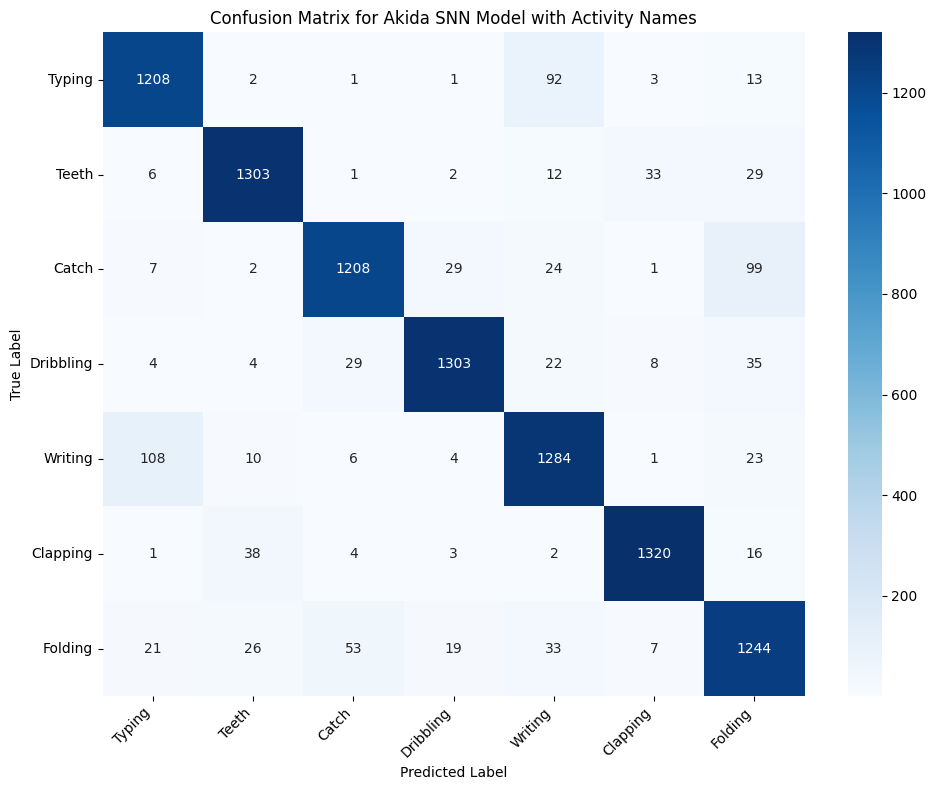

In [ ]:

# Calculate the confusion matrix
cm = confusion_matrix(y_test, akida_preds)

# Print the confusion matrix (optional)
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix using descriptive names
plt.figure(figsize=(10, 8)) # Adjust figure size for better readability of longer labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names_for_cm, yticklabels=activity_names_for_cm)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Akida SNN Model with Activity Names')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()